In [1]:
import os

for root, dirs, files in os.walk('../data/raw'):
    niveau = root.replace('../data/raw', '').count(os.sep)
    indent = ' ' * 2 * niveau
    print(f'{indent}{os.path.basename(root)}/')
    if niveau < 2:
        sous_indent = ' ' * 2 * (niveau + 1)
        for f in files[:5]:
            print(f'{sous_indent}{f}')
        if len(files) > 5:
            print(f'{sous_indent}... et {len(files)-5} autres fichiers')

raw/
  .gitkeep
  purchase_history.csv
  images/
    Styles/
    test/
    train/
    val/


In [2]:
import pandas as pd

# Regarder le fichier purchase_history
purchase_history = pd.read_csv('../data/raw/purchase_history.csv')
print("Shape :", purchase_history.shape)
print("\nColonnes :", purchase_history.columns.tolist())
purchase_history.head()

Shape : (52490, 10)

Colonnes : ['user_id', 'image_id', 'file_name', 'width', 'height', 'category', 'style', 'rating', 'season', 'occasion']


,user_id,image_id,file_name,width,height,category,style,rating,season,occasion
0,user_1,1,000001.jpg,468,624,sling dress,sling dress,5,summer,casual
1,user_1,1,000001.jpg,468,624,vest,vest,5,summer,casual
2,user_2,2,000002.jpg,468,624,sling dress,sling dress,5,summer,casual
3,user_2,2,000002.jpg,468,624,vest,vest,5,summer,casual
4,user_3,3,000003.jpg,468,628,short sleeve dress,short sleeve dress,5,summer,casual


In [3]:
print("Nombre d'utilisateurs uniques :", purchase_history['user_id'].nunique())
print("Nombre d'images uniques :", purchase_history['image_id'].nunique())
print("\nCatégories les plus fréquentes :")
print(purchase_history['category'].value_counts().head(15))
print("\nRépartition des saisons :")
print(purchase_history['season'].value_counts())
print("\nRépartition des occasions :")
print(purchase_history['occasion'].value_counts())

Nombre d'utilisateurs uniques : 100
Nombre d'images uniques : 32153

Catégories les plus fréquentes :
category
short sleeve top        12556
trousers                 9586
skirt                    6522
long sleeve top          5966
shorts                   4167
vest dress               3352
short sleeve dress       3127
vest                     2113
long sleeve outwear      2011
long sleeve dress        1477
sling dress              1149
sling                     322
short sleeve outwear      142
Name: count, dtype: int64

Répartition des saisons :
season
summer    52490
Name: count, dtype: int64

Répartition des occasions :
occasion
casual    52490
Name: count, dtype: int64


In [4]:
# Regarder toutes les pièces associées à une même image, pour comprendre la structure "tenue complète"
exemple_image = purchase_history[purchase_history['image_id'] == 1]
print(exemple_image[['image_id', 'file_name', 'category', 'style']])


   image_id   file_name     category        style
0         1  000001.jpg  sling dress  sling dress
1         1  000001.jpg         vest         vest


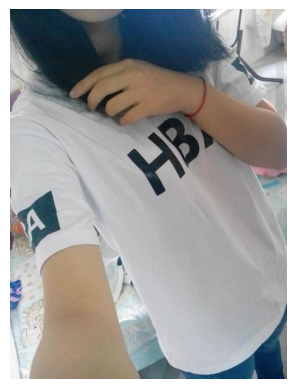

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('../data/raw/images/train/000001.jpg')
plt.imshow(img)
plt.axis('off')
plt.show()


In [6]:
import os

for split in ['train', 'val', 'test']:
    chemin = f'../data/raw/images/{split}'
    nb_fichiers = len(os.listdir(chemin))
    print(f"{split} : {nb_fichiers} images")

# Regardons aussi Styles/
chemin_styles = '../data/raw/images/Styles'
print(f"\nStyles : {len(os.listdir(chemin_styles))} fichiers")
print("Exemples :", os.listdir(chemin_styles)[:5])

train : 854 images
val : 296 images
test : 177 images

Styles : 49 fichiers
Exemples : ['image 1.jpg', 'image 10.jpg', 'image 11.png', 'image 12.jpg', 'image 13.jpg']


In [7]:
# Vérifions combien de file_name du CSV existent réellement dans train/
import os

fichiers_train = set(os.listdir('../data/raw/images/train'))
fichiers_val = set(os.listdir('../data/raw/images/val'))
fichiers_test = set(os.listdir('../data/raw/images/test'))
tous_fichiers_disponibles = fichiers_train | fichiers_val | fichiers_test

fichiers_dans_csv = set(purchase_history['file_name'].unique())

print("Fichiers référencés dans le CSV :", len(fichiers_dans_csv))
print("Fichiers réellement disponibles (train+val+test) :", len(tous_fichiers_disponibles))
print("Fichiers du CSV qu'on possède vraiment :", len(fichiers_dans_csv & tous_fichiers_disponibles))

Fichiers référencés dans le CSV : 32153
Fichiers réellement disponibles (train+val+test) : 854
Fichiers du CSV qu'on possède vraiment : 843


In [8]:
# On ne garde que les lignes du CSV correspondant à des images qu'on possède réellement
purchase_history_filtre = purchase_history[
    purchase_history['file_name'].isin(tous_fichiers_disponibles)
].copy()

print("Lignes après filtrage :", purchase_history_filtre.shape)
print("Images uniques après filtrage :", purchase_history_filtre['file_name'].nunique())
print("\nCatégories disponibles :")
print(purchase_history_filtre['category'].value_counts())

Lignes après filtrage : (1206, 10)
Images uniques après filtrage : 843

Catégories disponibles :
category
short sleeve top        287
skirt                   216
long sleeve top         155
trousers                151
short sleeve dress       82
vest dress               79
long sleeve dress        55
shorts                   42
long sleeve outwear      42
vest                     40
sling dress              35
sling                    19
short sleeve outwear      3
Name: count, dtype: int64
